In [28]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import accuracy_score, f1_score, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [29]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEEDS = [42, 123, 456]

In [30]:
agnews_train = pd.read_csv("agnews_clean_train.csv")
agnews_val   = pd.read_csv("agnews_clean_val.csv")
agnews_test  = pd.read_csv("agnews_clean_test.csv")

print(f"Train: {len(agnews_train)} | Val: {len(agnews_val)} | Test: {len(agnews_test)}")
print(f"Labels: {sorted(agnews_train['label'].unique())}")
print(agnews_train["label"].value_counts().sort_index())

Train: 18000 | Val: 2000 | Test: 7600
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
label
0    4500
1    4500
2    4500
3    4500
Name: count, dtype: int64


In [31]:

def tokenize(text):
    return str(text).lower().split()

def build_vocab(texts, max_vocab_size=20000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_vocab_size - 2):
        vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len=64):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

vocab = build_vocab(agnews_train["text"], max_vocab_size=20000)
VOCAB_SIZE = len(vocab)
MAX_LEN = 64
NUM_CLASSES = 4

print(f"Vocab size: {VOCAB_SIZE}")

Vocab size: 20000


In [32]:
class TextDataset(Dataset):
    def __init__(self, df, vocab, max_len=64):
        self.labels = df["label"].values
        self.encoded = [encode(t, vocab, max_len) for t in df["text"]]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.encoded[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

def get_loaders(train_df, val_df, test_df, vocab, max_len=64, batch_size=64):
    train_ds = TextDataset(train_df, vocab, max_len)
    val_ds   = TextDataset(val_df,   vocab, max_len)
    test_ds  = TextDataset(test_df,  vocab, max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_loaders(
    agnews_train, agnews_val, agnews_test,
    vocab, max_len=MAX_LEN, batch_size=64
)


In [ ]:
class FastText(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)    
        x = x.mean(dim=1)       
        x = self.dropout(x)
        return self.fc(x)

set_seed(42)
model = FastText(vocab_size=VOCAB_SIZE, embed_dim=64, num_classes=NUM_CLASSES).to(device)
dummy = torch.zeros(8, MAX_LEN, dtype=torch.long).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Output shape: torch.Size([8, 4])
Params: 1,280,260


In [34]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item() * len(y)
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += len(y)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    avg_loss = total_loss / total
    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1, all_preds, all_labels

In [ ]:
def run_experiment(train_loader, val_loader, test_loader,
                   vocab_size, num_classes, seed,
                   embed_dim=64, dropout=0.3,
                   lr=0.1, epochs=5):

    set_seed(seed)
    model = FastText(vocab_size, embed_dim, num_classes, dropout).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    scheduler = ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

    best_val_f1 = -1
    best_val_acc = -1
    best_epoch = 0
    best_model_state = None
    history = []

    train_start = time.time()

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)
        elapsed = time.time() - t0

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "epoch_time": elapsed
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.6f} | "
            f"val_f1: {val_f1:.6f} | "
            f"{elapsed:.1f}s"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            train_time = time.time() - train_start

    model.load_state_dict(best_model_state)

    t0 = time.time()
    _, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion)
    inference_time = time.time() - t0

    print(
        f"\nSeed {seed} -> "
        f"Best Val Acc: {best_val_acc:.6f} | "
        f"Best Val F1: {best_val_f1:.6f} | "
        f"Test Acc: {test_acc:.6f} | "
        f"Test F1: {test_f1:.6f} | "
        f"Inference: {inference_time:.2f}s"
    )

    return {
        "seed": seed,
        "model": model,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "test_preds": test_preds,
        "test_labels": test_labels,
        "train_time": train_time,
        "inference_time": inference_time,
        "history": history
    }


In [ ]:
print("\n" + "="*60)
print("Hyperparameter Tuning: Learning Rate")
print("="*60)

lr_candidates = [0.1, 0.5, 1.0]
lr_results = []

for lr in lr_candidates:
    print(f"\nTesting learning_rate = {lr}")

    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=42,
        lr=lr,
        epochs=5
    )

    lr_results.append({
        "learning_rate": lr,
        "best_val_acc": result["best_val_acc"],
        "best_epoch_reached": result["best_epoch"]
    })

lr_df = pd.DataFrame(lr_results)

print("\nLearning-rate tuning results:")
display(lr_df)

best_lr = lr_df.loc[lr_df["best_val_acc"].idxmax(), "learning_rate"]
print(f"\nBest learning rate (by validation accuracy): {best_lr}")


print("\n" + "="*60)
print("Hyperparameter Tuning: Epoch")
print("="*60)

epoch_candidates = [5, 10, 25]
epoch_results = []

for ep in epoch_candidates:
    print(f"\nTesting epochs = {ep}")

    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=42,
        lr=best_lr,
        epochs=ep
    )

    epoch_results.append({
        "epoch": ep,
        "best_val_acc": result["best_val_acc"],
        "best_epoch_reached": result["best_epoch"]
    })

epoch_df = pd.DataFrame(epoch_results)

print("\nEpoch tuning results:")
display(epoch_df)

best_epoch = epoch_df.loc[epoch_df["best_val_acc"].idxmax(), "epoch"]
print(f"\nBest epoch setting (by validation accuracy): {best_epoch}")


Hyperparameter Tuning: Learning Rate

Testing learning_rate = 0.1
Epoch 01 | train_loss: 0.4559 | val_loss: 0.3716 | val_acc: 0.882500 | val_f1: 0.882608 | 1.2s
Epoch 02 | train_loss: 0.1791 | val_loss: 0.4766 | val_acc: 0.864500 | val_f1: 0.864864 | 1.1s
Epoch 03 | train_loss: 0.0982 | val_loss: 0.7531 | val_acc: 0.856000 | val_f1: 0.857116 | 1.1s
Epoch 04 | train_loss: 0.0850 | val_loss: 0.8744 | val_acc: 0.863000 | val_f1: 0.862820 | 1.1s
Epoch 05 | train_loss: 0.0424 | val_loss: 0.9829 | val_acc: 0.864000 | val_f1: 0.863414 | 1.1s

Seed 42 -> Best Val Acc: 0.882500 | Best Val F1: 0.882608 | Test Acc: 0.889605 | Test F1: 0.889697 | Inference: 0.12s

Testing learning_rate = 0.5
Epoch 01 | train_loss: 2.0187 | val_loss: 2.4863 | val_acc: 0.820000 | val_f1: 0.820747 | 1.2s
Epoch 02 | train_loss: 3.0681 | val_loss: 4.3456 | val_acc: 0.838000 | val_f1: 0.837819 | 1.0s
Epoch 03 | train_loss: 3.5474 | val_loss: 6.6627 | val_acc: 0.839500 | val_f1: 0.839559 | 1.1s
Epoch 04 | train_loss: 3.

,learning_rate,best_val_acc,best_epoch_reached
0,0.1,0.8825,1
1,0.5,0.8600,5
2,1.0,0.8570,5



Best learning rate (by validation accuracy): 0.1

Hyperparameter Tuning: Epoch

Testing epochs = 5
Epoch 01 | train_loss: 0.4559 | val_loss: 0.3716 | val_acc: 0.882500 | val_f1: 0.882608 | 1.1s
Epoch 02 | train_loss: 0.1791 | val_loss: 0.4766 | val_acc: 0.864500 | val_f1: 0.864864 | 1.1s
Epoch 03 | train_loss: 0.0982 | val_loss: 0.7531 | val_acc: 0.856000 | val_f1: 0.857116 | 1.2s
Epoch 04 | train_loss: 0.0850 | val_loss: 0.8744 | val_acc: 0.863000 | val_f1: 0.862820 | 1.1s
Epoch 05 | train_loss: 0.0424 | val_loss: 0.9829 | val_acc: 0.864000 | val_f1: 0.863414 | 1.0s

Seed 42 -> Best Val Acc: 0.882500 | Best Val F1: 0.882608 | Test Acc: 0.889605 | Test F1: 0.889697 | Inference: 0.10s

Testing epochs = 10
Epoch 01 | train_loss: 0.4559 | val_loss: 0.3716 | val_acc: 0.882500 | val_f1: 0.882608 | 1.0s
Epoch 02 | train_loss: 0.1791 | val_loss: 0.4766 | val_acc: 0.864500 | val_f1: 0.864864 | 1.0s
Epoch 03 | train_loss: 0.0982 | val_loss: 0.7531 | val_acc: 0.856000 | val_f1: 0.857116 | 1.1s


,epoch,best_val_acc,best_epoch_reached
0,5,0.8825,1
1,10,0.8825,1
2,25,0.8825,1



Best epoch setting (by validation accuracy): 5


In [ ]:
results_agnews = []

for seed in SEEDS:
    result = run_experiment(
        train_loader, val_loader, test_loader,
        vocab_size=VOCAB_SIZE,
        num_classes=NUM_CLASSES,
        seed=seed,
        lr=best_lr,
        epochs=best_epoch
    )
    results_agnews.append(result)




Epoch 01 | train_loss: 0.4559 | val_loss: 0.3716 | val_acc: 0.882500 | val_f1: 0.882608 | 1.1s
Epoch 02 | train_loss: 0.1791 | val_loss: 0.4766 | val_acc: 0.864500 | val_f1: 0.864864 | 1.0s
Epoch 03 | train_loss: 0.0982 | val_loss: 0.7531 | val_acc: 0.856000 | val_f1: 0.857116 | 1.1s
Epoch 04 | train_loss: 0.0850 | val_loss: 0.8744 | val_acc: 0.863000 | val_f1: 0.862820 | 1.1s
Epoch 05 | train_loss: 0.0424 | val_loss: 0.9829 | val_acc: 0.864000 | val_f1: 0.863414 | 1.0s

Seed 42 -> Best Val Acc: 0.882500 | Best Val F1: 0.882608 | Test Acc: 0.889605 | Test F1: 0.889697 | Inference: 0.12s
Epoch 01 | train_loss: 0.4701 | val_loss: 0.3841 | val_acc: 0.878500 | val_f1: 0.878840 | 1.0s
Epoch 02 | train_loss: 0.1758 | val_loss: 0.5477 | val_acc: 0.859000 | val_f1: 0.859371 | 1.1s
Epoch 03 | train_loss: 0.1142 | val_loss: 0.6974 | val_acc: 0.852500 | val_f1: 0.851923 | 1.0s
Epoch 04 | train_loss: 0.0852 | val_loss: 0.8779 | val_acc: 0.853000 | val_f1: 0.852736 | 1.0s
Epoch 05 | train_loss: 0.0

,text,true,pred
211,"LETTER FROM EUROPE The All-Too-Human Hitler, o...",0,3
825,FCC Mulls Airborne Mobile Phone Use Although t...,2,3
78,MOM 2005 Released to Manufacturing Microsoft o...,2,3
67,Gregg: I will help to close deal EVERTON chair...,1,3
792,Prime minister says Australia faces tough econ...,0,2
731,Toshiba claims Hollywood backing in war for ne...,0,3
30,Hurricane center #39;s projection on Charley n...,3,2
292,Internet Emerging As Potent Terrorist Tool By ...,3,0
247,VoIP becomes new option Jackson is one of the ...,2,3
723,FDA OKs Scientist Publishing Vioxx Data (AP) A...,0,2



===== WORST MODEL ERRORS =====


,text,true,pred
199,Hyundai signs deal for China truck plant Hyund...,3,2
422,U.S. Seeks Reconciliation with Oil-Rich Venezu...,0,2
695,Patron Saint of the Nerds St. Expedite might n...,3,1
752,ConocoPhillips boosts LUKoil stake to 10 perce...,0,2
388,Siemens in 2.69bn deal with BBC German industr...,2,3
580,Another controversial Man Utd-Arsenal game Mou...,1,3
828,Death bell tolls for Russia's Yukos oil giant ...,0,2
530,Ramirez should be taking it to heart When it c...,1,3
494,Ljubicic Downs Hanescu at Open De Moselle Top-...,0,1
174,The Bahamas - the real medal winner of the Ath...,3,1


In [ ]:

def get_misclassified_examples(texts, true_labels, pred_labels):
    df = pd.DataFrame({
        "text": texts,
        "true": true_labels,
        "pred": pred_labels
    })
    df["correct"] = df["true"] == df["pred"]
    return df[df["correct"] == False].reset_index(drop=True)

fasttext_best_run = max(results_agnews, key=lambda x: x["test_acc"])

print("Selected FastText seed for error analysis:", fasttext_best_run["seed"])
print("FastText test_acc:", fasttext_best_run["test_acc"])
print("FastText test_f1:", fasttext_best_run["test_f1"])

fasttext_errors = get_misclassified_examples(
    agnews_test["text"].tolist(),
    fasttext_best_run["test_labels"],
    fasttext_best_run["test_preds"]
)

print("Total misclassified examples:", len(fasttext_errors))


fasttext_error_sample = fasttext_errors.sample(
    n=min(25, len(fasttext_errors)),
    random_state=42
).reset_index(drop=True)

print("\n===== 25 Misclassified Examples from FastText =====")
display(fasttext_error_sample[["text", "true", "pred"]])

fasttext_error_sample[["text", "true", "pred"]].to_csv(
    "fasttext_25_misclassified_examples.csv",
    index=False
)

print("\nSaved: fasttext_25_misclassified_examples.csv")

Selected FastText seed for error analysis: 42
FastText test_acc: 0.8896052631578948
FastText test_f1: 0.8896970829086227
Total misclassified examples: 839

===== 25 Misclassified Examples from FastText =====


,text,true,pred
0,"LETTER FROM EUROPE The All-Too-Human Hitler, o...",0,3
1,FCC Mulls Airborne Mobile Phone Use Although t...,2,3
2,MOM 2005 Released to Manufacturing Microsoft o...,2,3
3,Gregg: I will help to close deal EVERTON chair...,1,3
4,Prime minister says Australia faces tough econ...,0,2
5,Toshiba claims Hollywood backing in war for ne...,0,3
6,Hurricane center #39;s projection on Charley n...,3,2
7,Internet Emerging As Potent Terrorist Tool By ...,3,0
8,VoIP becomes new option Jackson is one of the ...,2,3
9,FDA OKs Scientist Publishing Vioxx Data (AP) A...,0,2



Saved: fasttext_25_misclassified_examples.csv


In [ ]:
results_df = pd.DataFrame([
    {
        "seed": r["seed"],
        "best_val_acc": r["best_val_acc"],
        "best_val_f1": r["best_val_f1"],
        "best_epoch": r["best_epoch"],
        "test_acc": r["test_acc"],
        "test_f1": r["test_f1"],
        "train_time": r["train_time"],
        "inference_time": r["inference_time"]
    }
    for r in results_agnews
])

print("Raw results:")
display(results_df)
results_df.to_csv("agnews_results.csv", index=False)


summary_df = pd.DataFrame({
    "metric": ["best_val_acc", "best_val_f1", "test_acc", "test_f1", "train_time", "inference_time"],
    "mean": [
        results_df["best_val_acc"].mean(),
        results_df["best_val_f1"].mean(),
        results_df["test_acc"].mean(),
        results_df["test_f1"].mean(),
        results_df["train_time"].mean(),
        results_df["inference_time"].mean()
    ],
    "std": [
        results_df["best_val_acc"].std(),
        results_df["best_val_f1"].std(),
        results_df["test_acc"].std(),
        results_df["test_f1"].std(),
        results_df["train_time"].std(),
        results_df["inference_time"].std()
    ]
})

print("\nSummary statistics:")
display(summary_df)
summary_df.to_csv("agnews_summary.csv", index=False)

Raw results:


,seed,best_val_acc,best_val_f1,best_epoch,test_acc,test_f1,train_time,inference_time
0,42,0.8825,0.882608,1,0.889605,0.889697,1.113282,0.114589
1,123,0.8785,0.878840,1,0.875263,0.876070,1.130466,0.170106
2,456,0.8785,0.878774,1,0.874342,0.875134,1.136566,0.112353



Summary statistics:


,metric,mean,std
0,best_val_acc,0.879833,0.002309
1,best_val_f1,0.880074,0.002195
2,test_acc,0.879737,0.008559
3,test_f1,0.880300,0.008151
4,train_time,1.126771,0.012074
5,inference_time,0.132349,0.032717


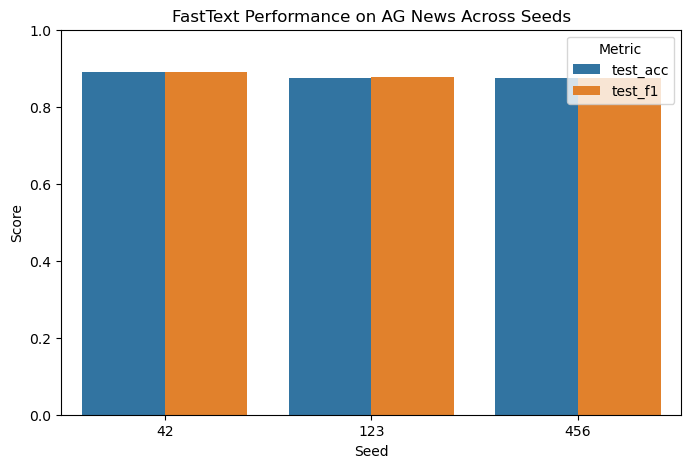

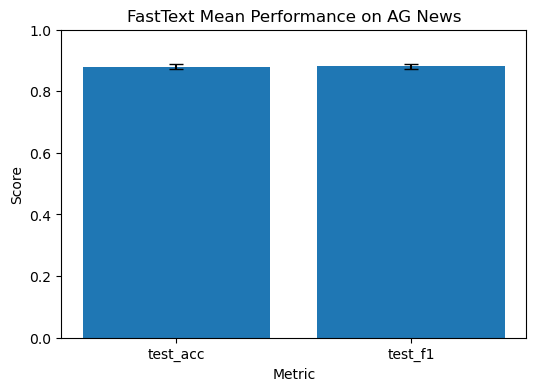


Report-ready summary:
FastText achieved a mean test accuracy of 0.8797 ± 0.0086, and a mean macro-F1 of 0.8803 ± 0.0082 across 3 random seeds.
Average training time: 1.13s ± 0.01s
Average inference time: 0.13s ± 0.03s


In [ ]:
plot_df = results_df.melt(
    id_vars="seed",
    value_vars=["test_acc", "test_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="seed", y="score", hue="metric")
plt.title("FastText Performance on AG News Across Seeds")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xlabel("Seed")
plt.legend(title="Metric")
plt.savefig("agnews_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

perf_summary = summary_df[summary_df["metric"].isin(["test_acc", "test_f1"])]

plt.figure(figsize=(6, 4))
plt.bar(
    perf_summary["metric"],
    perf_summary["mean"],
    yerr=perf_summary["std"],
    capsize=5
)
plt.title("FastText Mean Performance on AG News")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.savefig("agnews_mean_performance.png", dpi=300, bbox_inches="tight")
plt.show()


print("\nReport-ready summary:")
print(
    f"FastText achieved a mean test accuracy of "
    f"{results_df['test_acc'].mean():.4f} ± {results_df['test_acc'].std():.4f}, "
    f"and a mean macro-F1 of "
    f"{results_df['test_f1'].mean():.4f} ± {results_df['test_f1'].std():.4f} "
    f"across {len(results_df)} random seeds."
)
print(
    f"Average training time: "
    f"{results_df['train_time'].mean():.2f}s ± {results_df['train_time'].std():.2f}s"
)

print(
    f"Average inference time: "
    f"{results_df['inference_time'].mean():.2f}s ± {results_df['inference_time'].std():.2f}s"
)


In [ ]:
fractions = [1.0, 0.5, 0.25, 0.10, 0.05, 0.01]
efficiency_results = []

def stratified_subset(df, frac, seed=42):
    parts = []
    for _, group in df.groupby("label"):
        n = max(1, int(round(len(group) * frac)))
        sampled = group.sample(n=n, random_state=seed)
        parts.append(sampled)
    subset = pd.concat(parts, axis=0).sample(frac=1, random_state=seed).reset_index(drop=True)
    return subset

print("\n" + "="*70)
print("DATA EFFICIENCY EXPERIMENT")
print("Using fixed full-training vocabulary for fair comparison")
print(f"best_lr = {best_lr}, best_epoch = {best_epoch}")
print("="*70)

for frac in fractions:
    print(f"\n{'='*60}")
    print(f"Running FastText on {int(frac * 100)}% of training data")
    print(f"{'='*60}")

    train_subset = stratified_subset(agnews_train, frac, seed=42)

    print(f"Train size: {len(train_subset)}")
    print(train_subset["label"].value_counts().sort_index())

    train_loader_eff, val_loader_eff, test_loader_eff = get_loaders(
        train_subset,
        agnews_val,
        agnews_test,
        vocab,              
        max_len=MAX_LEN,
        batch_size=64
    )

    for seed in SEEDS:
        print(f"\n--- Fraction {frac}, Seed {seed} ---")

        result = run_experiment(
            train_loader_eff,
            val_loader_eff,
            test_loader_eff,
            vocab_size=VOCAB_SIZE,  
            num_classes=NUM_CLASSES,
            seed=seed,
            lr=best_lr,
            epochs=best_epoch
        )

        efficiency_results.append({
            "fraction": frac,
            "train_size": len(train_subset),
            "seed": result["seed"],
            "best_val_acc": result["best_val_acc"],
            "test_acc": result["test_acc"],
            "test_f1": result["test_f1"],
            "train_time": result["train_time"],
            "inference_time": result["inference_time"]
        })


efficiency_df = pd.DataFrame(efficiency_results)

print("\nFull Data Efficiency Results:")
display(efficiency_df)

efficiency_df.to_csv("data_efficiency_full.csv", index=False)


efficiency_summary = (
    efficiency_df
    .groupby("fraction", as_index=False)
    .agg({
        "train_size": "first",
        "test_acc": ["mean", "std"],
        "test_f1": ["mean", "std"],
        "train_time": ["mean", "std"],
        "inference_time": ["mean", "std"]
    })
)

efficiency_summary.columns = [
    "fraction",
    "train_size",
    "mean_test_acc",
    "std_test_acc",
    "mean_test_f1",
    "std_test_f1",
    "mean_train_time",
    "std_train_time",
    "mean_inference_time",
    "std_inference_time"
]

efficiency_summary = efficiency_summary.sort_values("fraction", ascending=False).reset_index(drop=True)

print("\nSummary Data Efficiency Results:")
display(efficiency_summary)

efficiency_summary.to_csv("data_efficiency_summary.csv", index=False)


DATA EFFICIENCY EXPERIMENT
Using fixed full-training vocabulary for fair comparison
best_lr = 0.1, best_epoch = 5

Running FastText on 100% of training data
Train size: 18000
label
0    4500
1    4500
2    4500
3    4500
Name: count, dtype: int64

--- Fraction 1.0, Seed 42 ---
Epoch 01 | train_loss: 0.4613 | val_loss: 0.4168 | val_acc: 0.883000 | val_f1: 0.882756 | 1.2s
Epoch 02 | train_loss: 0.1728 | val_loss: 0.5403 | val_acc: 0.855000 | val_f1: 0.855437 | 1.1s
Epoch 03 | train_loss: 0.1114 | val_loss: 0.7295 | val_acc: 0.858000 | val_f1: 0.858408 | 1.1s
Epoch 04 | train_loss: 0.0952 | val_loss: 0.9701 | val_acc: 0.865000 | val_f1: 0.864869 | 1.0s
Epoch 05 | train_loss: 0.0479 | val_loss: 0.9083 | val_acc: 0.861500 | val_f1: 0.861854 | 1.0s

Seed 42 -> Best Val Acc: 0.883000 | Best Val F1: 0.882756 | Test Acc: 0.893289 | Test F1: 0.892866 | Inference: 0.10s

--- Fraction 1.0, Seed 123 ---
Epoch 01 | train_loss: 0.4657 | val_loss: 0.3696 | val_acc: 0.888000 | val_f1: 0.888202 | 1.0s


,fraction,train_size,seed,best_val_acc,test_acc,test_f1,train_time,inference_time
0,1.00,18000,42,0.8830,0.893289,0.892866,1.239246,0.102099
1,1.00,18000,123,0.8880,0.887500,0.887651,0.988485,0.121792
2,1.00,18000,456,0.8965,0.885395,0.885282,1.137501,0.102912
3,0.50,9000,42,0.8860,0.880395,0.880458,0.498573,0.100438
4,0.50,9000,123,0.8725,0.872895,0.873305,0.498081,0.099804
5,0.50,9000,456,0.8760,0.868684,0.868062,0.514123,0.105233
6,0.25,4500,42,0.8655,0.848816,0.848889,0.545000,0.102305
7,0.25,4500,123,0.8625,0.856974,0.856734,1.364389,0.105863
8,0.25,4500,456,0.8640,0.857105,0.856449,1.361166,0.103735
9,0.10,1800,42,0.8385,0.834342,0.834541,0.397062,0.106549



Summary Data Efficiency Results:


,fraction,train_size,mean_test_acc,std_test_acc,mean_test_f1,std_test_f1,mean_train_time,std_train_time,mean_inference_time,std_inference_time
0,1.00,18000,0.888728,0.004088,0.888599,0.003880,1.121744,0.126121,0.108934,0.011143
1,0.50,9000,0.873991,0.005932,0.873942,0.006223,0.503592,0.009123,0.101825,0.002969
2,0.25,4500,0.854298,0.004748,0.854024,0.004449,1.090185,0.472147,0.103968,0.001790
3,0.10,1800,0.835658,0.002055,0.835852,0.001917,0.472073,0.065773,0.107407,0.001975
4,0.05,900,0.807281,0.004737,0.807180,0.004972,0.320813,0.071205,0.101858,0.003276
5,0.01,180,0.657281,0.012275,0.657369,0.010114,0.199208,0.007250,0.106735,0.003235
